In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("cell_eval_results.csv")
df_gold = pd.read_parquet("../../data/cell/cell_papers_all_novelty_scores.parquet")


df.columns = ['PaperProjectID', 'openalex', 'TrustScore']
df["openalex"] = df["openalex"].apply(lambda x: x[len("https://openalex.org/"):])

In [10]:
df.columns, df_gold.columns

(Index(['PaperProjectID', 'openalex', 'TrustScore'], dtype='str'),
 Index(['pubmed_id', 'openalex', 'novelty_sum', 'top5_novel', 'top10_novel',
        'wangs_novelty', 'dindex', 'forward_citations_openalex', 'new_finding',
        'originality'],
       dtype='str'))

In [11]:
df_gold.info()

<class 'pandas.DataFrame'>
RangeIndex: 6770 entries, 0 to 6769
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pubmed_id                   6770 non-null   str    
 1   openalex                    6616 non-null   str    
 2   novelty_sum                 6770 non-null   float64
 3   top5_novel                  6770 non-null   bool   
 4   top10_novel                 6770 non-null   bool   
 5   wangs_novelty               4106 non-null   float64
 6   dindex                      6482 non-null   float64
 7   forward_citations_openalex  6616 non-null   float64
 8   new_finding                 6770 non-null   float64
 9   originality                 6770 non-null   float64
dtypes: bool(2), float64(6), str(2)
memory usage: 561.3 KB


In [12]:
all_df = df.merge(df_gold, on='openalex', how='left')
all_df

,PaperProjectID,openalex,TrustScore,pubmed_id,novelty_sum,top5_novel,top10_novel,wangs_novelty,dindex,forward_citations_openalex,new_finding,originality
0,0,W1965843055,0.083793,11779465,1.0,False,False,NaN,-0.009080,711.0,1.0,0.855799
1,1,W2046221312,0.078004,11779463,1.0,False,False,NaN,-0.004666,303.0,0.0,0.805782
2,2,W2150589615,0.075911,11779461,8.0,True,True,NaN,-0.010714,820.0,7.0,0.890620
3,3,W2087575288,0.089192,11779460,1.0,False,False,NaN,-0.007171,305.0,1.0,0.902148
4,4,W1989011389,0.089492,11779462,0.0,False,False,NaN,-0.051230,1142.0,0.0,0.816867
...,...,...,...,...,...,...,...,...,...,...,...,...
6036,6036,W3092921638,0.088005,33053319,0.0,False,False,1.330732,-0.002130,170.0,0.0,0.876770
6037,6037,W3097197008,0.125074,33125892,0.0,False,False,3.915213,-0.000452,493.0,0.0,0.886570
6038,6038,W3097788036,0.120345,33125891,0.0,False,False,10.946048,-0.000243,232.0,0.0,0.922636
6039,6039,W3092142510,0.175325,33035454,0.0,False,False,0.000000,-0.001103,134.0,0.0,0.640524


In [13]:
all_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6041 entries, 0 to 6040
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PaperProjectID              6041 non-null   int64  
 1   openalex                    6041 non-null   str    
 2   TrustScore                  6041 non-null   float64
 3   pubmed_id                   5917 non-null   str    
 4   novelty_sum                 5917 non-null   float64
 5   top5_novel                  5917 non-null   object 
 6   top10_novel                 5917 non-null   object 
 7   wangs_novelty               3265 non-null   float64
 8   dindex                      5876 non-null   float64
 9   forward_citations_openalex  5917 non-null   float64
 10  new_finding                 5917 non-null   float64
 11  originality                 5917 non-null   float64
dtypes: float64(7), int64(1), object(2), str(2)
memory usage: 677.4+ KB


In [ ]:
score_columns = [col for col in all_df.columns if col not in ['PaperProjectID', 'openalex', 'pubmed_id']]
all_df["TrustScore_exp"] = all_df["TrustScore"].apply(lambda x: np.log(x))

corr = all_df[score_columns].corr(numeric_only=True, method='spearman')


In [18]:
corr

,TrustScore,novelty_sum,wangs_novelty,dindex,forward_citations_openalex,new_finding,originality,TrustScore_exp
TrustScore,1.000000,-0.022402,0.112110,0.117194,-0.075437,-0.026742,0.102674,1.000000
novelty_sum,-0.022402,1.000000,0.044604,-0.045141,0.248096,0.937472,0.001009,-0.022402
wangs_novelty,0.112110,0.044604,1.000000,0.188813,0.067022,0.037119,0.521257,0.112110
dindex,0.117194,-0.045141,0.188813,1.000000,-0.244104,-0.069480,0.284441,0.117194
forward_citations_openalex,-0.075437,0.248096,0.067022,-0.244104,1.000000,0.242647,0.023913,-0.075437
new_finding,-0.026742,0.937472,0.037119,-0.069480,0.242647,1.000000,-0.018855,-0.026742
originality,0.102674,0.001009,0.521257,0.284441,0.023913,-0.018855,1.000000,0.102674
TrustScore_exp,1.000000,-0.022402,0.112110,0.117194,-0.075437,-0.026742,0.102674,1.000000


In [8]:
all_df = all_df[df['TrustScore'] != -1]

In [46]:
corr = all_df[['TrustScore', 'novelty_sum', 'top5_novel', 'wangs_novelty', 'dindex']].corr()

In [47]:
corr

,TrustScore,novelty_sum,top5_novel,wangs_novelty,dindex
TrustScore,1.000000,-0.034975,-0.006730,NaN,0.174109
novelty_sum,-0.034975,1.000000,0.663353,NaN,0.069207
top5_novel,-0.006730,0.663353,1.000000,NaN,0.109141
wangs_novelty,NaN,NaN,NaN,NaN,NaN
dindex,0.174109,0.069207,0.109141,NaN,1.000000


In [48]:
all_df['TrustScore'].min()

np.float64(0.0411734580993652)

In [27]:
all_df["top10_ours"] = (all_df["TrustScore"] > all_df['TrustScore'].quantile(0.90))
all_df["top10_novel"] = all_df["top10_novel"].astype(bool)

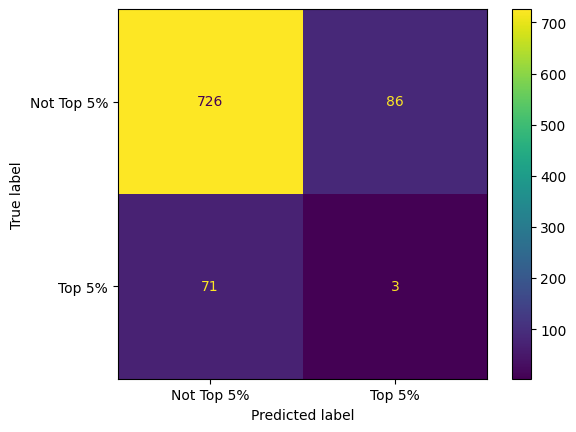

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_df['top10_novel'], all_df['top10_ours'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Top 5%', 'Top 5%'])
disp.plot()

In [29]:
all_df['top5_novel'].info()

<class 'pandas.Series'>
Index: 886 entries, 0 to 890
Series name: top5_novel
Non-Null Count  Dtype
--------------  -----
886 non-null    bool 
dtypes: bool(1)
memory usage: 7.8 KB


In [30]:
all_df['top5_ours'].info()

<class 'pandas.Series'>
Index: 886 entries, 0 to 890
Series name: top5_ours
Non-Null Count  Dtype
--------------  -----
886 non-null    bool 
dtypes: bool(1)
memory usage: 7.8 KB
